# Analysis Notebook

This notebook performs the main statistical and advanced analysis for the global colorectal cancer study. It uses the processed master dataset generated by `data_processing.ipynb` and produces the correlation matrix, normality tests, regional comparison tests, regression models, PCA tables, PCA figures, and Middle East comparison tests used in the paper.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from scipy.stats import shapiro
from scipy.stats import spearmanr
from pathlib import Path
from scipy.stats import kruskal

In [5]:
OUTPUT_DIR = Path("outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = OUTPUT_DIR / "processed_all_master.csv"

FIGURE_PATH = FIGURE_DIR / "figure_4_5_spearman_correlation_heatmap.png"
CORR_TABLE_PATH = TABLE_DIR / "table_4_2_spearman_correlation_matrix.csv"
PVAL_TABLE_PATH = TABLE_DIR / "table_4_2_spearman_p_values.csv"

## Correlation Analysis

Spearman rank correlations among colorectal cancer incidence, obesity prevalence, physical activity prevalence, and log GDP per capita

In [6]:
df = pd.read_csv(DATA_PATH)


# Select variables
variables = {
    "Colorectal cancer ASR": "asr_world",
    "Obesity prevalence (%)": "obesity_value",
    "Physical activity prevalence (%)": "activity_value",
    "Log GDP per capita": "log_gdp"
}

data = df[list(variables.values())].dropna()
data = data.rename(columns={v: k for k, v in variables.items()})

print(f"Spearman analysis sample size: n = {len(data)} countries")

Spearman analysis sample size: n = 173 countries


Saved correlation table to: outputs\tables\table_4_2_spearman_correlation_matrix.csv
Saved p-value table to: outputs\tables\table_4_2_spearman_p_values.csv


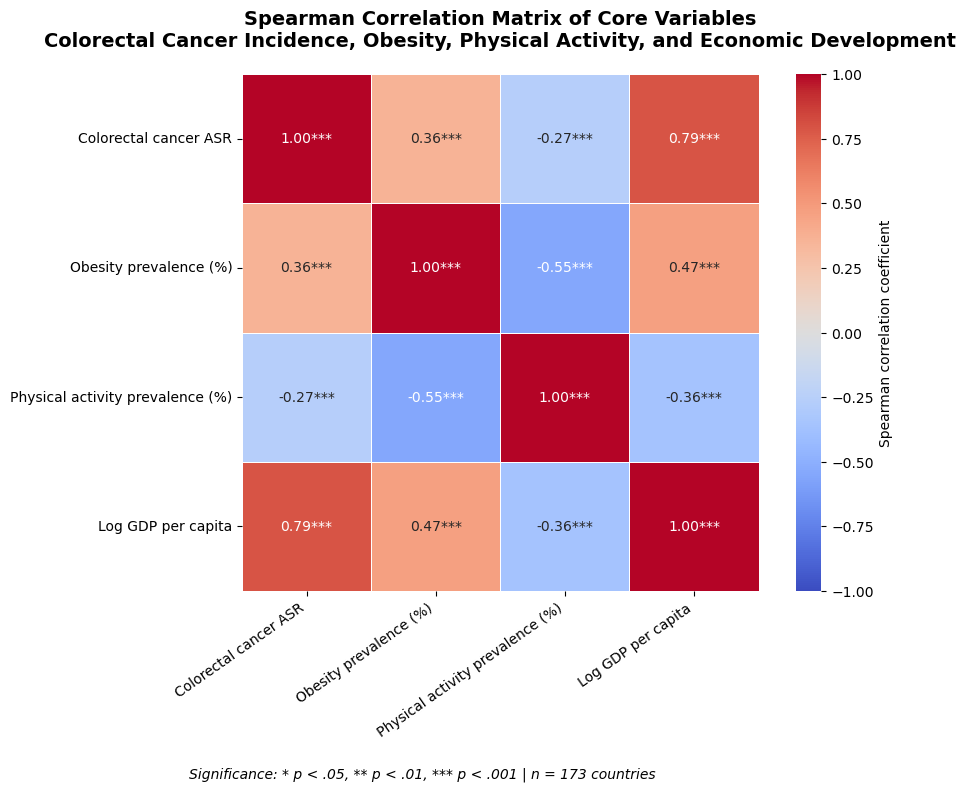

Saved heatmap to: outputs\figures\figure_4_5_spearman_correlation_heatmap.png


In [7]:
# Spearman correlation matrix and p-value matrix
corr_matrix = data.corr(method="spearman")

p_matrix = pd.DataFrame(index=data.columns, columns=data.columns, dtype=float)

for col1 in data.columns:
    for col2 in data.columns:
        rho, p = spearmanr(data[col1], data[col2])
        p_matrix.loc[col1, col2] = p

# Annotation with significance stars
def stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

annot = corr_matrix.copy().astype(str)

for row in corr_matrix.index:
    for col in corr_matrix.columns:
        r = corr_matrix.loc[row, col]
        p = p_matrix.loc[row, col]
        annot.loc[row, col] = f"{r:.2f}{stars(p)}"

# Save tables
corr_matrix.round(4).to_csv(CORR_TABLE_PATH)
p_matrix.round(6).to_csv(PVAL_TABLE_PATH)

print("Saved correlation table to:", CORR_TABLE_PATH)
print("Saved p-value table to:", PVAL_TABLE_PATH)


# Plot and save Spearman heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=annot,
    fmt="",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation coefficient"}
)

plt.title(
    "Spearman Correlation Matrix of Core Variables\n"
    "Colorectal Cancer Incidence, Obesity, Physical Activity, and Economic Development",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

plt.figtext(
    0.5,
    0.02,
    f"Significance: * p < .05, ** p < .01, *** p < .001 | n = {len(data)} countries",
    ha="center",
    fontsize=10,
    style="italic"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved heatmap to:", FIGURE_PATH)

# Infernetials Statistics

## Normality Assessment

Shapiro-Wilk tests to the core continuous variables to justify non-parametric correlation and regional comparison tests.

In [8]:
# Shapiro-Wilk normality tests for core continuous variables

TABLE_DIR = Path("outputs/tables")

shapiro_variables = {
    "Colorectal cancer ASR": "asr_world",
    "Obesity prevalence (%)": "obesity_value",
    "Physical activity prevalence (%)": "activity_value",
    "Log GDP per capita": "log_gdp"
}

shapiro_results = []

for label, col in shapiro_variables.items():
    values = df[col].dropna()
    stat, p_value = shapiro(values)
    
    shapiro_results.append({
        "Variable": label,
        "n": len(values),
        "Shapiro-Wilk W": round(stat, 4),
        "p-value": round(p_value, 6),
        "Interpretation": "Non-normal" if p_value < 0.05 else "Not significantly non-normal"
    })

shapiro_table = pd.DataFrame(shapiro_results)

display(shapiro_table)

shapiro_table.to_csv(TABLE_DIR / "table_4_1_shapiro_wilk_tests.csv", index=False)

shapiro_table.to_latex(
    TABLE_DIR / "table_4_1_shapiro_wilk_tests.tex",
    index=False,
    escape=False,
    caption="Shapiro-Wilk normality tests for core continuous variables.",
    label="tab:shapiro_wilk_tests"
)

,Variable,n,Shapiro-Wilk W,p-value,Interpretation
0,Colorectal cancer ASR,173,0.9127,0.000000,Non-normal
1,Obesity prevalence (%),173,0.9779,0.007437,Non-normal
2,Physical activity prevalence (%),173,0.9648,0.000234,Non-normal
3,Log GDP per capita,173,0.9800,0.013521,Non-normal


C:\Users\Raihan Karim Ishmam\AppData\Local\Temp\ipykernel_19640\865243409.py:32: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  shapiro_table.to_latex(


## Regional Differences: Kruskal-Wallis Tests

In [9]:
# Kruskal-Wallis tests for regional differences


kruskal_variables = {
    "Colorectal cancer ASR": "asr_world",
    "Obesity prevalence (%)": "obesity_value",
    "Physical activity prevalence (%)": "activity_value",
    "Log GDP per capita": "log_gdp"
}

kruskal_results = []

for label, col in kruskal_variables.items():
    groups = [
        group[col].dropna()
        for _, group in df.groupby("region")
        if len(group[col].dropna()) > 0
    ]
    
    stat, p_value = kruskal(*groups)
    
    kruskal_results.append({
        "Variable": label,
        "Number of regions": df["region"].nunique(),
        "Kruskal-Wallis H": round(stat, 4),
        "p-value": round(p_value, 6),
        "Interpretation": "Significant regional difference" if p_value < 0.05 else "No significant regional difference"
    })

kruskal_table = pd.DataFrame(kruskal_results)

display(kruskal_table)

kruskal_table.to_csv(TABLE_DIR / "table_4_3_kruskal_wallis_tests.csv", index=False)

kruskal_table.to_latex(
    TABLE_DIR / "table_4_3_kruskal_wallis_tests.tex",
    index=False,
    escape=False,
    caption="Kruskal-Wallis tests for regional differences in colorectal cancer ASR, obesity, physical activity, and log GDP.",
    label="tab:kruskal_wallis_tests"
)

,Variable,Number of regions,Kruskal-Wallis H,p-value,Interpretation
0,Colorectal cancer ASR,6,100.6207,0.0,Significant regional difference
1,Obesity prevalence (%),6,90.7523,0.0,Significant regional difference
2,Physical activity prevalence (%),6,74.5916,0.0,Significant regional difference
3,Log GDP per capita,6,91.5631,0.0,Significant regional difference


C:\Users\Raihan Karim Ishmam\AppData\Local\Temp\ipykernel_19640\4077309965.py:36: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  kruskal_table.to_latex(


## Regression Models

Estimating regression models predicting colorectal cancer incidence using lifestyle variables, log GDP per capita, and regional controls.

In [10]:
# Regression models predicting colorectal cancer ASR

reg_df = df[[
    "cancer_index",
    "obesity_value",
    "activity_value",
    "log_gdp",
    "region"
]].dropna().copy()

model_1 = smf.ols(
    "cancer_index ~ obesity_value + activity_value",
    data=reg_df
).fit()

model_2 = smf.ols(
    "cancer_index ~ obesity_value + activity_value + log_gdp",
    data=reg_df
).fit()

model_3 = smf.ols(
    "cancer_index ~ obesity_value + activity_value + log_gdp + C(region)",
    data=reg_df
).fit()

models = {
    "Model 1: Lifestyle only": model_1,
    "Model 2: Lifestyle + GDP": model_2,
    "Model 3: Lifestyle + GDP + Region": model_3
}

regression_rows = []

for model_name, model in models.items():
    conf = model.conf_int()
    
    for term in model.params.index:
        regression_rows.append({
            "Model": model_name,
            "Term": term,
            "Coefficient": round(model.params[term], 4),
            "Std. Error": round(model.bse[term], 4),
            "p-value": round(model.pvalues[term], 6),
            "95% CI Lower": round(conf.loc[term, 0], 4),
            "95% CI Upper": round(conf.loc[term, 1], 4)
        })

regression_table = pd.DataFrame(regression_rows)

model_fit_rows = []

for model_name, model in models.items():
    model_fit_rows.append({
        "Model": model_name,
        "n": int(model.nobs),
        "R-squared": round(model.rsquared, 4),
        "Adjusted R-squared": round(model.rsquared_adj, 4),
        "AIC": round(model.aic, 2),
        "BIC": round(model.bic, 2)
    })

model_fit_table = pd.DataFrame(model_fit_rows)

display(regression_table)
display(model_fit_table)

regression_table.to_csv(TABLE_DIR / "table_4_4_regression_coefficients.csv", index=False)
model_fit_table.to_csv(TABLE_DIR / "table_4_4_regression_model_fit.csv", index=False)

regression_table.to_latex(
    TABLE_DIR / "table_4_4_regression_coefficients.tex",
    index=False,
    escape=False,
    caption="Regression coefficients for models predicting colorectal cancer incidence ASR.",
    label="tab:regression_coefficients"
)

model_fit_table.to_latex(
    TABLE_DIR / "table_4_4_regression_model_fit.tex",
    index=False,
    escape=False,
    caption="Model fit statistics for regression models predicting colorectal cancer incidence ASR.",
    label="tab:regression_model_fit"
)

print(model_1.summary())
print(model_2.summary())
print(model_3.summary())

,Model,Term,Coefficient,Std. Error,p-value,95% CI Lower,95% CI Upper
0,Model 1: Lifestyle only,Intercept,11.9148,6.4210,0.065243,-0.7604,24.5901
1,Model 1: Lifestyle only,obesity_value,0.2508,0.0860,0.004034,0.0810,0.4206
2,Model 1: Lifestyle only,activity_value,-0.0166,0.0716,0.817369,-0.1578,0.1247
3,Model 2: Lifestyle + GDP,Intercept,-44.7474,5.6254,0.000000,-55.8526,-33.6422
4,Model 2: Lifestyle + GDP,obesity_value,-0.0420,0.0595,0.481376,-0.1594,0.0754
5,Model 2: Lifestyle + GDP,activity_value,0.0917,0.0473,0.054327,-0.0017,0.1851
6,Model 2: Lifestyle + GDP,log_gdp,6.2671,0.4143,0.000000,5.4493,7.0849
7,Model 3: Lifestyle + GDP + Region,Intercept,-16.2990,5.8487,0.005952,-27.8476,-4.7505
8,Model 3: Lifestyle + GDP + Region,C(region)[T.Americas],1.7106,1.8391,0.353662,-1.9207,5.3420
9,Model 3: Lifestyle + GDP + Region,C(region)[T.Asia],2.3774,1.4392,0.100466,-0.4643,5.2191


,Model,n,R-squared,Adjusted R-squared,AIC,BIC
0,Model 1: Lifestyle only,173,0.0677,0.0568,1311.47,1320.93
1,Model 2: Lifestyle + GDP,173,0.6040,0.5970,1165.35,1177.96
2,Model 3: Lifestyle + GDP + Region,173,0.7339,0.7210,1106.54,1134.92


C:\Users\Raihan Karim Ishmam\AppData\Local\Temp\ipykernel_19640\1912629076.py:70: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  regression_table.to_latex(


                            OLS Regression Results                            
Dep. Variable:           cancer_index   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     6.177
Date:                Sat, 23 May 2026   Prob (F-statistic):            0.00257
Time:                        20:22:33   Log-Likelihood:                -652.73
No. Observations:                 173   AIC:                             1311.
Df Residuals:                     170   BIC:                             1321.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         11.9148      6.421      1.

C:\Users\Raihan Karim Ishmam\AppData\Local\Temp\ipykernel_19640\1912629076.py:78: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  model_fit_table.to_latex(


## PCA variance and loading tables

In [11]:
pca_cols = [
    "z_cancer_index",
    "z_obesity",
    "z_physical_activity",
    "z_log_gdp"
]

pca_labels = [
    "Colorectal cancer ASR",
    "Obesity prevalence",
    "Physical activity prevalence",
    "Log GDP per capita"
]

pca_df = df[pca_cols].dropna().copy()

pca = PCA(n_components=4)
pca_scores = pca.fit_transform(pca_df)

explained_variance_table = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(4)],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Explained Variance (%)": pca.explained_variance_ratio_ * 100,
    "Cumulative Variance (%)": np.cumsum(pca.explained_variance_ratio_) * 100
})

explained_variance_table = explained_variance_table.round(3)

loadings_table = pd.DataFrame(
    pca.components_.T,
    index=pca_labels,
    columns=[f"PC{i+1}" for i in range(4)]
).reset_index()

loadings_table = loadings_table.rename(columns={"index": "Variable"})
loadings_table.iloc[:, 1:] = loadings_table.iloc[:, 1:].round(3)

display(explained_variance_table)
display(loadings_table)

explained_variance_table.to_csv(TABLE_DIR / "table_4_5_pca_explained_variance.csv", index=False)
loadings_table.to_csv(TABLE_DIR / "table_4_6_pca_loadings.csv", index=False)

explained_variance_table.to_latex(
    TABLE_DIR / "table_4_5_pca_explained_variance.tex",
    index=False,
    escape=False,
    caption="PCA explained variance and cumulative explained variance.",
    label="tab:pca_explained_variance"
)

loadings_table.to_latex(
    TABLE_DIR / "table_4_6_pca_loadings.tex",
    index=False,
    escape=False,
    caption="PCA loadings for standardized colorectal cancer, obesity, physical activity, and log GDP variables.",
    label="tab:pca_loadings"
)

,Principal Component,Explained Variance Ratio,Explained Variance (%),Cumulative Variance (%)
0,PC1,0.562,56.187,56.187
1,PC2,0.266,26.631,82.818
2,PC3,0.121,12.131,94.950
3,PC4,0.051,5.050,100.000


,Variable,PC1,PC2,PC3,PC4
0,Colorectal cancer ASR,-0.509,0.555,-0.087,-0.652
1,Obesity prevalence,-0.476,-0.454,0.745,-0.114
2,Physical activity prevalence,0.410,0.620,0.658,0.121
3,Log GDP per capita,-0.589,0.318,-0.069,0.740


C:\Users\Raihan Karim Ishmam\AppData\Local\Temp\ipykernel_19640\3294476561.py:44: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  explained_variance_table.to_latex(
C:\Users\Raihan Karim Ishmam\AppData\Local\Temp\ipykernel_19640\3294476561.py:52: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  loadings_table.to_latex(


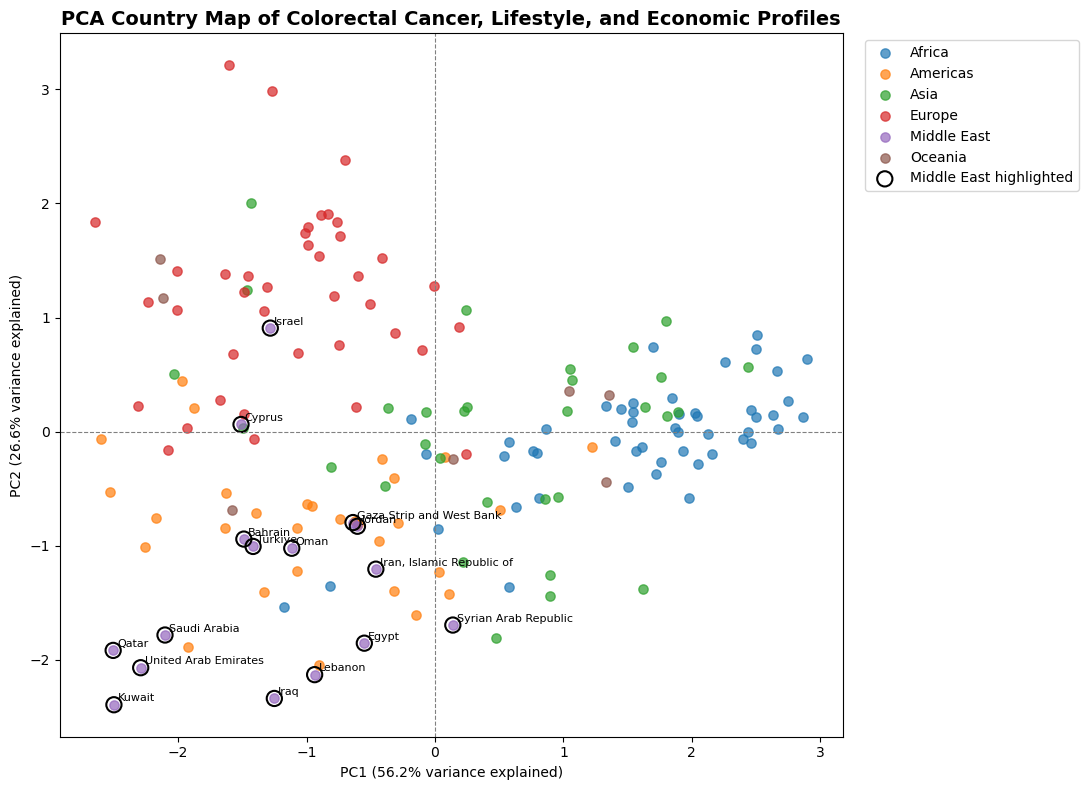

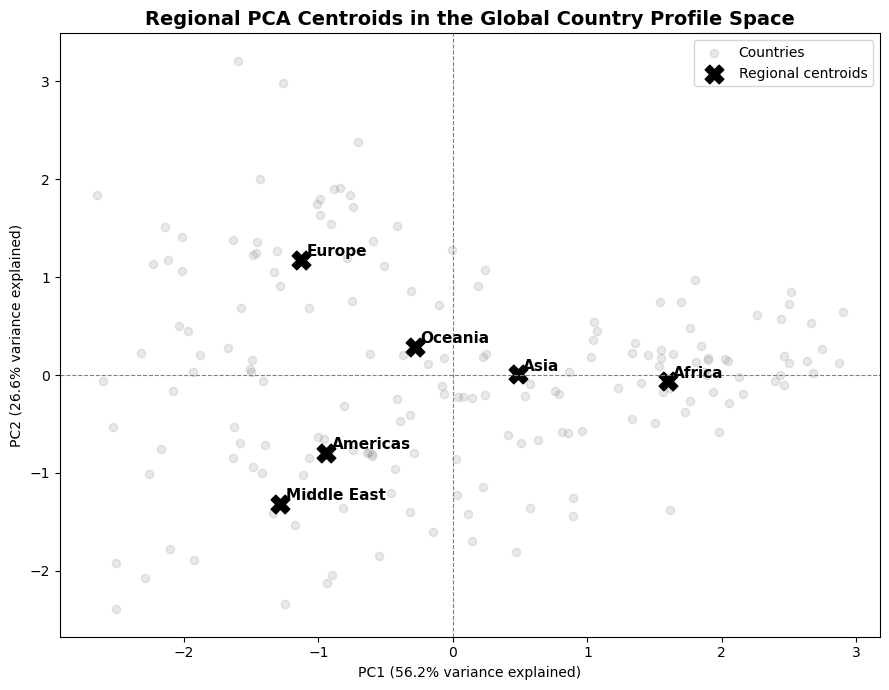

In [12]:
# PCA country map and regional centroid plot using the already fitted PCA object

FIGURE_DIR = Path("outputs/figures")

# Attach PC1 and PC2 scores to the same countries used in PCA
pca_plot_df = df.loc[pca_df.index, [
    "country_name",
    "region",
    "middle_east_flag"
]].copy()

pca_plot_df["PC1"] = pca_scores[:, 0]
pca_plot_df["PC2"] = pca_scores[:, 1]

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

# Save PCA country scores
pca_plot_df.to_csv(
    TABLE_DIR / "table_4_7_pca_country_scores.csv",
    index=False
)

# Figure 4.8: PCA country map
plt.figure(figsize=(11, 8))

for region in sorted(pca_plot_df["region"].dropna().unique()):
    region_data = pca_plot_df[pca_plot_df["region"] == region]
    plt.scatter(
        region_data["PC1"],
        region_data["PC2"],
        s=45,
        alpha=0.70,
        label=region
    )

middle_east_data = pca_plot_df[pca_plot_df["middle_east_flag"] == 1]

plt.scatter(
    middle_east_data["PC1"],
    middle_east_data["PC2"],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Middle East highlighted"
)

for _, row in middle_east_data.iterrows():
    plt.text(
        row["PC1"] + 0.03,
        row["PC2"] + 0.03,
        row["country_name"],
        fontsize=8
    )

plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.xlabel(f"PC1 ({pc1_var:.1f}% variance explained)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance explained)")
plt.title(
    "PCA Country Map of Colorectal Cancer, Lifestyle, and Economic Profiles",
    fontsize=14,
    fontweight="bold"
)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "figure_4_8_pca_country_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Regional centroid calculation
centroids = (
    pca_plot_df
    .groupby("region")[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

centroids.to_csv(
    TABLE_DIR / "table_4_8_pca_regional_centroids.csv",
    index=False
)

# Figure 4.9: Regional PCA centroids
plt.figure(figsize=(9, 7))

plt.scatter(
    pca_plot_df["PC1"],
    pca_plot_df["PC2"],
    s=35,
    alpha=0.18,
    color="gray",
    label="Countries"
)

plt.scatter(
    centroids["PC1"],
    centroids["PC2"],
    s=180,
    marker="X",
    color="black",
    label="Regional centroids"
)

for _, row in centroids.iterrows():
    plt.text(
        row["PC1"] + 0.04,
        row["PC2"] + 0.04,
        row["region"],
        fontsize=11,
        fontweight="bold"
    )

plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.xlabel(f"PC1 ({pc1_var:.1f}% variance explained)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance explained)")
plt.title(
    "Regional PCA Centroids in the Global Country Profile Space",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "figure_4_9_pca_regional_centroids.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Middle East vs Non-Middle East Comparison

In [13]:
# Middle East vs non-Middle East comparison using Mann-Whitney U tests

comparison_variables = {
    "Colorectal cancer ASR": "asr_world",
    "Obesity prevalence (%)": "obesity_value",
    "Physical activity prevalence (%)": "activity_value",
    "Log GDP per capita": "log_gdp"
}

# Make Middle East flag robust in case it is stored as True/False, 1/0, or text
me_flag = df["middle_east_flag"].astype(str).str.lower().isin(["true", "1", "yes"])

middle_east_df = df[me_flag].copy()
non_middle_east_df = df[~me_flag].copy()

me_results = []

for label, col in comparison_variables.items():
    me_values = middle_east_df[col].dropna()
    non_me_values = non_middle_east_df[col].dropna()
    
    u_stat, p_value = mannwhitneyu(
        me_values,
        non_me_values,
        alternative="two-sided"
    )
    
    me_results.append({
        "Variable": label,
        "Middle East n": len(me_values),
        "Non-Middle East n": len(non_me_values),
        "Middle East median": round(me_values.median(), 3),
        "Non-Middle East median": round(non_me_values.median(), 3),
        "Middle East mean": round(me_values.mean(), 3),
        "Non-Middle East mean": round(non_me_values.mean(), 3),
        "Mann-Whitney U": round(u_stat, 3),
        "p-value": round(p_value, 6),
        "Interpretation": "Significant difference" if p_value < 0.05 else "No significant difference"
    })

middle_east_comparison_table = pd.DataFrame(me_results)

display(middle_east_comparison_table)

middle_east_comparison_table.to_csv(
    TABLE_DIR / "table_4_9_middle_east_vs_non_middle_east_tests.csv",
    index=False
)

middle_east_comparison_table.to_latex(
    TABLE_DIR / "table_4_9_middle_east_vs_non_middle_east_tests.tex",
    index=False,
    escape=False,
    caption="Mann-Whitney U tests comparing Middle Eastern and non-Middle Eastern countries across core analytical variables.",
    label="tab:middle_east_vs_non_middle_east"
)

,Variable,Middle East n,Non-Middle East n,Middle East median,Non-Middle East median,Middle East mean,Non-Middle East mean,Mann-Whitney U,p-value,Interpretation
0,Colorectal cancer ASR,16,157,12.300,12.400,14.050,16.401,1268.0,0.951950,No significant difference
1,Obesity prevalence (%),16,157,35.035,21.000,34.501,20.540,2182.5,0.000001,Significant difference
2,Physical activity prevalence (%),16,157,57.365,77.220,55.485,74.643,329.0,0.000001,Significant difference
3,Log GDP per capita,16,157,9.675,8.713,9.485,8.733,1634.0,0.047930,Significant difference


C:\Users\Raihan Karim Ishmam\AppData\Local\Temp\ipykernel_19640\3409261913.py:50: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  middle_east_comparison_table.to_latex(
